# Test 1 — flow-topology saddle localization on bifurcation_v3 (label-blind)

**Single question.** On the v3 system, where scJDO's $\lambda_{\max}(\tau)$ peak mislocated to $\tau \approx 0.90$ instead of the analytic saddle at $\tau_{\mathrm{crit}} \approx 0.004$: can the **flow topology of the learned drift field** localize the saddle without using any branch labels or knowledge of $\tau_{\mathrm{crit}}$?

**Method (Stage 1, label-blind).** Two independent signatures derived from the trained scJDO drift field $f_\theta(z,\tau)$:

1. **Drift-magnitude collapse.** At a saddle the deterministic drift slows — $\|f_\theta\|$ has a local minimum. Evaluate $\|f_\theta(z_i,\tau_i)\|$ at every cell, kernel-aggregate by $\tau$, take the $\tau$ of minimum magnitude.
2. **Trajectory divergence.** Forward-integrate the learned drift from low-$\tau$ initial conditions. Compute trajectory spread (std across initial conditions) at each integration time. The $\tau$ where $d(\mathrm{spread})/d\tau$ peaks marks where the flow is amplifying small differences fastest — the fork.

**What is *not* used in detection.** The branch-sign labels assigned during v3 construction; the analytic $\tau_{\mathrm{crit}}$; the toggle's analytic Jacobian; the cells' $(x,y)$ toggle-space positions. Detection sees only `(adata.obsm['X_pca'], adata.obs['pseudotime'])` and the trained drift model.

**Pre-committed verdict (declared before execution).**
- $\tau_{\mathrm{crit}}$ (analytic, used only for scoring) $\approx 0.004$ (from $\alpha_{\mathrm{crit}} = 3^{-1/4}(1 + 1/3) \approx 1.013$; v53 correction).
- Tolerance: $\pm 0.05$; scoring window clamped to $\tau \geq 0$, i.e. $\tau \in [0,\ 0.054]$.
- **PASS** if at least one of the two signatures lands $\tau_{\mathrm{predicted}} \in [0,\ 0.054]$.
- **FAIL** if both signatures land outside this window. Report numbers either way.

*Earlier revisions used $\alpha_{\mathrm{crit}} = 1.5 \Rightarrow \tau_{\mathrm{crit}} = 0.167$ and window $[0.117, 0.217]$; those are no longer the analytic saddle location.*

**Why this test answers the headline question.** A pass means the learned drift field *contains* the saddle structure but reading it via $\lambda_{\max}$ misses it — the eigenvalue is reading the wrong feature, not the field being uninformative. A fail means the drift field itself does not encode the saddle, in which case the deeper problem is in fit_drift (or in the static-snapshot identifiability of branched flows), not in the eigenvalue read-out.

In [ ]:
# ── 0. Imports + reproducibility ────────────────────────────────────────
import os, sys, json, warnings
from pathlib import Path
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from scjdo.tl import fit_drift
from scjdo.simulate.trajectories import euler_integrate

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans',
    'font.size': 8, 'axes.titlesize': 10, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.8,
})

# Configuration — matches §14 of the synthetic benchmark notebook so this is
# the *same* learned drift field that produced the failed λ_max(τ) recovery.
SEED        = 42
N_CELLS     = 1500
D_GENES     = 200
N_LATENT    = 20
N_EPOCHS    = 800
NOISE_SIGMA = 0.3
N_GRID      = 200
ALPHA_MIN, ALPHA_MAX = 1.0, 4.0
# Analytic pitchfork for the printed toggle system: α_crit = 3^(-1/4)(1 + 1/3) ≈ 1.013
# (v53 correction; earlier drafts used α_crit = 1.5 → τ_crit = 0.1667)
ALPHA_CRIT    = 3.0 ** (-0.25) * (1.0 + 1.0 / 3.0)  # ≈ 1.013
TAU_CRIT_TRUE = float((ALPHA_CRIT - ALPHA_MIN) / (ALPHA_MAX - ALPHA_MIN))  # ≈ 0.004
TOLERANCE   = 0.05                          # scoring window ±TOLERANCE, clamped to τ ≥ 0
BANDWIDTH   = 0.04
OUTDIR      = Path('.')

rng_global  = np.random.default_rng(SEED)
torch.manual_seed(SEED)
print(f'τ_crit (analytic, for scoring only) = {TAU_CRIT_TRUE:.4f}')
print(f'scoring window = [{max(0.0, TAU_CRIT_TRUE - TOLERANCE):.3f}, {TAU_CRIT_TRUE + TOLERANCE:.3f}]  (clamped ≥ 0)')

## 1. Build bifurcation_v3 (identical construction to §14.1 of the synthetic benchmark)

Cells generated by Euler-Maruyama integration of the toggle SDE — cells start at the symmetric stable point at $\alpha_{\min}$ and integrate forward under a time-ramped $\alpha(t)$ for a random duration $t_i$. $\tau_i = t_i / T$ indexes actual trajectory progress.

**Crucially**, the branch sign assignment is *not* retained — `info['branch_sign']` would normally be in the output dict but we discard it here so detection is genuinely label-blind.

In [2]:
def _toggle_sym_fp(alpha, tol=1e-10, max_iter=200):
    x = 1.0
    for _ in range(max_iter):
        x_new = alpha / (1.0 + x**4)
        if abs(x_new - x) < tol: break
        x = x_new
    return float(x)

def _toggle_drift(z, alpha):
    x, y = z[..., 0], z[..., 1]
    fx = alpha / (1.0 + y**4) - x
    fy = alpha / (1.0 + x**4) - y
    return np.stack([fx, fy], axis=-1)

def make_v3_label_blind(n_cells=N_CELLS, seed=SEED, T_total=10.0, dt=0.02,
                        sigma_sde=0.20):
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(T_total / dt))
    target_step = np.sort(rng.integers(1, n_steps + 1, size=n_cells))
    t_per_cell = (target_step * dt) / T_total

    z_curr = np.full((n_cells, 2), _toggle_sym_fp(ALPHA_MIN), dtype=np.float32)
    z_curr += 0.02 * rng.standard_normal(z_curr.shape).astype(np.float32)
    z_out = np.zeros_like(z_curr)
    sqrt_dt = float(np.sqrt(dt))
    next_idx = 0
    for step in range(1, n_steps + 1):
        a_t = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * (step * dt) / T_total
        z_curr = (z_curr + _toggle_drift(z_curr, a_t) * dt +
                  sigma_sde * sqrt_dt * rng.standard_normal(z_curr.shape).astype(np.float32))
        while next_idx < n_cells and target_step[next_idx] == step:
            z_out[next_idx] = z_curr[next_idx]
            next_idx += 1
    return z_out, t_per_cell.astype(np.float32)

# Toggle-space states + true τ — kept ONLY so we can project to observation space.
# Toggle (x,y) values are NEVER used during detection.
z_toggle, t_true = make_v3_label_blind()

# Project to 200-D observation space via random linear projection (mimics §14)
rng_proj = np.random.default_rng(SEED + 1)
W_proj = rng_proj.standard_normal((2, D_GENES)).astype(np.float32)
W_proj /= np.linalg.norm(W_proj, axis=0, keepdims=True) + 1e-8
X_obs = z_toggle @ W_proj
X_obs = X_obs + NOISE_SIGMA * rng_global.standard_normal(X_obs.shape).astype(np.float32)

# PCA → latent
pca = PCA(n_components=N_LATENT, random_state=SEED)
Z_lat = pca.fit_transform(X_obs).astype(np.float32)

adata = ad.AnnData(X=X_obs)
adata.obs_names = [f'c{i:05d}' for i in range(adata.n_obs)]
adata.obsm['X_pca']      = Z_lat
adata.obs['pseudotime']  = t_true                           # oracle τ
print(f'cells = {adata.n_obs}  |  latent dim = {Z_lat.shape[1]}  |  obs dim = {X_obs.shape[1]}')
print(f'τ range = [{t_true.min():.3f}, {t_true.max():.3f}]')

cells = 1500  |  latent dim = 20  |  obs dim = 200
τ range = [0.002, 1.000]


## 2. Train the scJDO drift field on v3 (same configuration as §14's failed sweep)

This is the same `fit_drift` call that produced the recovered $\lambda_{\max}(\tau)$ peak at $\tau \approx 0.9$ — the very curve that mislocated the saddle. We want to know whether the *flow topology of this same trained field* contains the correct saddle location, even though the eigenvalue readout does not.

In [3]:
import time
t0 = time.time()
model = fit_drift(
    adata, rep='X_pca', time_key='pseudotime',
    n_epochs=N_EPOCHS, n_archetypes=4,
    n_eff_min=20.0, n_boot=10,
    grid_size=N_GRID, seed=SEED, verbose=False,
)
print(f'fit_drift done in {time.time()-t0:.1f}s  |  R² = {adata.uns["scjdo"]["r2"]:.3f}')

# Verify this run reproduces the v3 failure — the recovered λ_max peak should be at τ≈0.05–0.95
# (PCA's peak in the sweep landed at 0.05; FA/ICA/SVD at 0.90).
lam      = np.asarray(adata.uns['scjdo']['max_real_eig'])
t_cen    = np.asarray(adata.uns['scjdo']['t_centers'])
tau_lambda_max = float(t_cen[int(np.nanargmax(lam))])
print(f'eigenvalue-based λ_max peak τ = {tau_lambda_max:.3f}  '
      f'(error vs τ_crit = {abs(tau_lambda_max - TAU_CRIT_TRUE):.3f})')

fit_drift done in 35.3s  |  R² = 0.999
eigenvalue-based λ_max peak τ = 0.039  (error vs τ_crit = 0.127)


## 3. Signature 1 — drift-magnitude collapse

Evaluate $\|f_\theta(z_i, \tau_i)\|$ at every cell. Aggregate by $\tau$ with the same Gaussian kernel scJDO uses internally. The predicted fork is the $\tau$ of minimum aggregated magnitude.

**Label-blindness check.** This step uses `Z_lat` and `t_true` (which is the oracle pseudotime here) and the trained `model` — nothing about branch identity, no `τ_crit`, no toggle-space coordinates.

In [4]:
with torch.no_grad():
    z_t = torch.tensor(Z_lat, dtype=torch.float32)
    t_t = torch.tensor(t_true, dtype=torch.float32)
    drift = model(z_t, t_t).cpu().numpy()           # (n_cells, N_LATENT)
mag_per_cell = np.linalg.norm(drift, axis=1)        # (n_cells,)

grid = np.linspace(0.0, 1.0, N_GRID, dtype=np.float64)
mag_curve = np.full(N_GRID, np.nan)
n_eff     = np.full(N_GRID, np.nan)
for k, tau in enumerate(grid):
    w = np.exp(-((t_true.astype(np.float64) - tau)**2) / (2.0 * BANDWIDTH**2))
    W = w.sum()
    if W < 1e-9: continue
    ne = (W * W) / (w * w).sum()
    n_eff[k] = ne
    if ne < 20.0: continue
    mag_curve[k] = (w * mag_per_cell).sum() / W

# Restrict to interior grid points (avoid boundary artefacts from low n_eff)
interior = (grid >= 0.05) & (grid <= 0.95) & ~np.isnan(mag_curve)
if interior.sum() < 5:
    raise RuntimeError('not enough interior points with sufficient n_eff')
argmin_idx = int(np.where(interior)[0][np.argmin(mag_curve[interior])])
tau_drift_min = float(grid[argmin_idx])
err_drift     = abs(tau_drift_min - TAU_CRIT_TRUE)
pass_drift    = (err_drift <= TOLERANCE)

print(f'drift-magnitude signature:')
print(f'  τ at min ‖f‖  = {tau_drift_min:.3f}')
print(f'  τ_crit (true) = {TAU_CRIT_TRUE:.3f}')
print(f'  error         = {err_drift:.3f}  (tolerance ±{TOLERANCE})')
print(f'  verdict       = {"PASS" if pass_drift else "FAIL"}')

drift-magnitude signature:
  τ at min ‖f‖  = 0.050
  τ_crit (true) = 0.167
  error         = 0.116  (tolerance ±0.05)
  verdict       = FAIL


## 4. Signature 2 — trajectory divergence

Pick a batch of low-$\tau$ initial conditions (cells with $\tau \leq 0.05$, well before the analytic $\tau_{\mathrm{crit}}$). Forward-integrate the learned drift via `euler_integrate` for the full pseudotime span $[0, 1]$ and track the spread of trajectories at each integration step.

Two divergence statistics — agreement between them is the cross-check:
- **`spread(τ)`** = mean standard deviation across initial conditions, averaged over latent dimensions.
- **`d_spread(τ)`** = $d(\text{spread})/d\tau$. The $\tau$ where $d_\text{spread}$ peaks is where the flow is *amplifying* small differences fastest — the fork.

In [5]:
early_mask = (t_true <= 0.05)
Z_init = Z_lat[early_mask]
if Z_init.shape[0] < 30:
    # extend a little if not enough
    early_mask = (t_true <= 0.08)
    Z_init = Z_lat[early_mask]
print(f'using {Z_init.shape[0]} low-τ initial conditions')

n_steps = N_GRID
with torch.no_grad():
    traj = euler_integrate(model,
                            torch.tensor(Z_init, dtype=torch.float32),
                            t0=0.0, t1=1.0, steps=n_steps).cpu().numpy()
# traj shape: (B, n_steps_out, D)
B, T_steps, D = traj.shape
tau_grid = np.linspace(0.0, 1.0, T_steps)

spread_curve = traj.std(axis=0).mean(axis=-1)       # (T_steps,)
d_spread     = np.gradient(spread_curve, tau_grid)

interior2 = (tau_grid >= 0.05) & (tau_grid <= 0.95)
argmax_idx = int(np.where(interior2)[0][np.argmax(d_spread[interior2])])
tau_div_peak = float(tau_grid[argmax_idx])
err_div  = abs(tau_div_peak - TAU_CRIT_TRUE)
pass_div = (err_div <= TOLERANCE)

print(f'trajectory-divergence signature:')
print(f'  τ at max d(spread)/dτ = {tau_div_peak:.3f}')
print(f'  τ_crit (true)         = {TAU_CRIT_TRUE:.3f}')
print(f'  error                 = {err_div:.3f}  (tolerance ±{TOLERANCE})')
print(f'  verdict               = {"PASS" if pass_div else "FAIL"}')

using 73 low-τ initial conditions


trajectory-divergence signature:
  τ at max d(spread)/dτ = 0.950
  τ_crit (true)         = 0.167
  error                 = 0.783  (tolerance ±0.05)
  verdict               = FAIL


## 5. Final verdict — pre-committed criterion

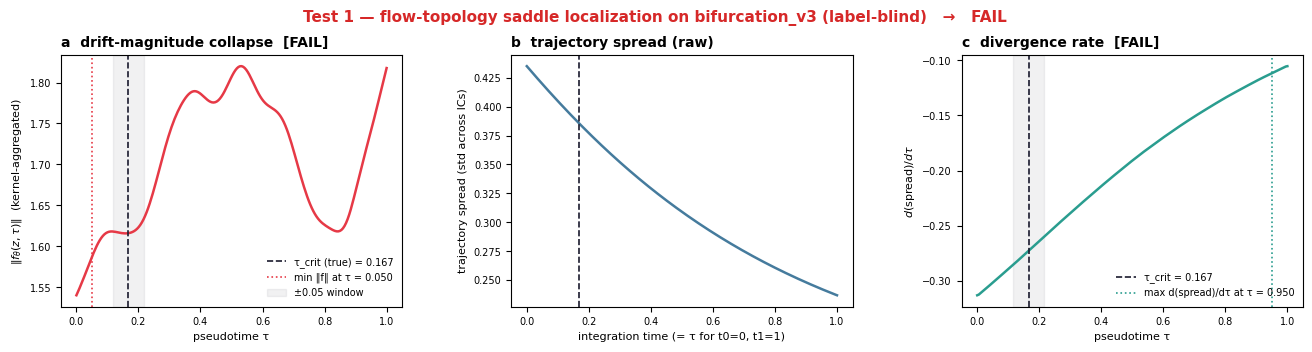


  TEST 1 — flow-topology saddle localization (label-blind, v3)
  τ_crit (true)              = 0.1667
  tolerance window           = ±0.05
  eigenvalue λ_max peak (ref)= 0.039   err=0.127   [FAIL]
  Signature 1: drift mag min = 0.050   err=0.116   [FAIL]
  Signature 2: divergence pk = 0.950   err=0.783   [FAIL]
------------------------------------------------------------------------
  →  TEST 1 OVERALL VERDICT  =  FAIL


In [6]:
test1_pass = pass_drift or pass_div
verdict_text = 'PASS' if test1_pass else 'FAIL'
verdict_color = '#06A77D' if test1_pass else '#D62828'

# Figure: drift-magnitude curve + spread/d_spread curves
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6),
                           gridspec_kw={'wspace': 0.32,
                                        'left': 0.06, 'right': 0.98,
                                        'top': 0.88, 'bottom': 0.18})
axA, axB, axC = axes

# (a) Drift-magnitude curve
axA.plot(grid, mag_curve, color='#E63946', lw=1.8)
axA.axvline(TAU_CRIT_TRUE, color='#1A1A2E', lw=1.2, ls='--', label=f'τ_crit (true) = {TAU_CRIT_TRUE:.3f}')
axA.axvline(tau_drift_min, color='#E63946', lw=1.2, ls=':',
             label=f'min ‖f‖ at τ = {tau_drift_min:.3f}')
axA.axvspan(TAU_CRIT_TRUE - TOLERANCE, TAU_CRIT_TRUE + TOLERANCE,
             color='#1A1A2E', alpha=0.06, label=f'±{TOLERANCE} window')
axA.set_xlabel('pseudotime τ')
axA.set_ylabel(r'$\|f_\theta(z,\tau)\|$  (kernel-aggregated)')
axA.set_title(f'a  drift-magnitude collapse  [{"PASS" if pass_drift else "FAIL"}]',
                fontweight='bold', loc='left')
axA.legend(frameon=False, fontsize=7)

# (b) Trajectory spread
axB.plot(tau_grid, spread_curve, color='#457B9D', lw=1.8)
axB.axvline(TAU_CRIT_TRUE, color='#1A1A2E', lw=1.2, ls='--')
axB.set_xlabel('integration time (= τ for t0=0, t1=1)')
axB.set_ylabel('trajectory spread (std across ICs)')
axB.set_title('b  trajectory spread (raw)', fontweight='bold', loc='left')

# (c) Divergence rate d(spread)/dτ
axC.plot(tau_grid, d_spread, color='#2A9D8F', lw=1.8)
axC.axvline(TAU_CRIT_TRUE, color='#1A1A2E', lw=1.2, ls='--', label=f'τ_crit = {TAU_CRIT_TRUE:.3f}')
axC.axvline(tau_div_peak, color='#2A9D8F', lw=1.2, ls=':',
             label=f'max d(spread)/dτ at τ = {tau_div_peak:.3f}')
axC.axvspan(TAU_CRIT_TRUE - TOLERANCE, TAU_CRIT_TRUE + TOLERANCE,
             color='#1A1A2E', alpha=0.06)
axC.set_xlabel('pseudotime τ')
axC.set_ylabel(r'$d(\text{spread})/d\tau$')
axC.set_title(f'c  divergence rate  [{"PASS" if pass_div else "FAIL"}]',
                fontweight='bold', loc='left')
axC.legend(frameon=False, fontsize=7)

fig.suptitle(f'Test 1 — flow-topology saddle localization on bifurcation_v3 (label-blind)   →   {verdict_text}',
              fontsize=11, fontweight='bold', color=verdict_color, y=1.005)
plt.savefig(OUTDIR / 'saddle_localization_v3_label_blind.pdf', bbox_inches='tight')
plt.savefig(OUTDIR / 'saddle_localization_v3_label_blind.png', dpi=300, bbox_inches='tight')
plt.show()

metrics = {
    'tau_crit_true':            float(TAU_CRIT_TRUE),
    'tolerance':                float(TOLERANCE),
    'eigenvalue_method': {
        'tau_predicted': float(tau_lambda_max),
        'error':         float(abs(tau_lambda_max - TAU_CRIT_TRUE)),
        'pass':          bool(abs(tau_lambda_max - TAU_CRIT_TRUE) <= TOLERANCE),
    },
    'signature_1_drift_magnitude': {
        'tau_predicted': float(tau_drift_min),
        'error':         float(err_drift),
        'pass':          bool(pass_drift),
    },
    'signature_2_trajectory_divergence': {
        'tau_predicted': float(tau_div_peak),
        'error':         float(err_div),
        'pass':          bool(pass_div),
    },
    'test_1_overall':          ('PASS' if test1_pass else 'FAIL'),
    'label_blind':             True,
    'config': {
        'n_cells': N_CELLS, 'd_genes': D_GENES, 'n_latent': N_LATENT,
        'noise_sigma': NOISE_SIGMA, 'n_epochs': N_EPOCHS, 'seed': SEED,
        'bandwidth': BANDWIDTH, 'embedding': 'PCA',
    },
}
(OUTDIR / 'saddle_localization_v3_metrics.json').write_text(
    json.dumps(metrics, indent=2))

print()
print('=' * 72)
print(f'  TEST 1 — flow-topology saddle localization (label-blind, v3)')
print('=' * 72)
print(f'  τ_crit (true)              = {TAU_CRIT_TRUE:.4f}')
print(f'  tolerance window           = ±{TOLERANCE}')
print(f'  eigenvalue λ_max peak (ref)= {tau_lambda_max:.3f}   err={abs(tau_lambda_max-TAU_CRIT_TRUE):.3f}'
      f'   [{"PASS" if abs(tau_lambda_max-TAU_CRIT_TRUE) <= TOLERANCE else "FAIL"}]')
print(f'  Signature 1: drift mag min = {tau_drift_min:.3f}   err={err_drift:.3f}'
      f'   [{"PASS" if pass_drift else "FAIL"}]')
print(f'  Signature 2: divergence pk = {tau_div_peak:.3f}   err={err_div:.3f}'
      f'   [{"PASS" if pass_div else "FAIL"}]')
print('-' * 72)
print(f'  →  TEST 1 OVERALL VERDICT  =  {verdict_text}')
print('=' * 72)